#Preparación del entorno

In [ ]:
from IPython.utils import io #Proporciona herramientas para capturar y suprimir las salidas (outputs).
import tqdm.notebook #Proporciona una barra de progreso interactiva para el notebook Jupyter.
import os, os.path, sys, random, subprocess #Proporciona funciones para interactuar con el sistema operativo, como manipular archivos y directorios.
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
        pbar.update(20)
        !pip install matplotlib, seaborn, pandas
        '''Librerías gráficas'''
        import matplotlib.pyplot as plt
        from IPython.display import display, SVG, HTML #Muestra gráficos SVG en el notebook
        import seaborn as sns #Librería para visualización de datos estadísticos basada en matplotlib.
        !pip install rdkit
        from rdkit import Chem
        from rdkit.Chem import Draw
        pbar.update(40)
        '''Librerias de herramientas primarias:'''
        import pandas as pd #Librería para manipulación y análisis de datos tabulares en Python.
        %config Completer.use_jedi = False
        import json #Proporciona herramientas para trabajar con datos en formato JSON.
        pbar.update(30)
        '''Busqueda en ChEMBL (API)'''
        !pip install chembl_webresource_client
        from chembl_webresource_client.new_client import new_client #Proporciona un nuevo cliente para acceder a la API de ChEMBL.
        from chembl_webresource_client.utils import utils #Proporciona funciones de utilidad para trabajar con la API de ChEMBL.
        from pathlib import Path #Proporciona manipulación de rutas de archivos como clases independientes.
        '''Montar unidad de Google Drive'''
        from google.colab import drive #Proporciona herramientas para montar y acceder a Google Drive desde Google Colab.
        drive.mount("/content/drive")
        pbar.update(10)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
#Instalar MolVS
!pip install -q molvs

In [ ]:
pip install dash-bootstrap-components

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.5/222.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 18.2 MB/s eta 0:00:00


In [ ]:
#Importar librerías necesarias
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import rdMolDescriptors
from molvs.standardize import Standardizer
from molvs.charge import Uncharger, Reionizer
from molvs.fragment import LargestFragmentChooser
from molvs.tautomer import TautomerCanonicalizer
from rdkit.Chem.rdmolops import GetFormalCharge, RemoveStereochemistry

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

#Concatenar las bases de datos y sumar la base de datos de farmacos aprobados por la FDA actualizacion 2022

In [ ]:
import pandas as pd
import numpy as np
import sys
from sklearn.preprocessing import StandardScaler
import dash_bootstrap_components as dbc
from sys import argv

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

In [ ]:
# Leer bases de datos
#FDA
url_fda = "https://raw.githubusercontent.com/DIFACQUIM/Cursos/main/Datasets/FDA_2022_july_05_curada.csv"
FDA = pd.read_csv(url_fda)
FDA.head(2)

,ID,SMILES,NEW_SMILES,Data set
0,DB00006,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA
1,DB00007,CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(N)=N)NC(=...,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA


In [ ]:
# Leer base de datos desde Drive
#DATA_P
url_DATA_P = "/content/drive/MyDrive/Doctorado/Set de datos/3. Descriptores moleculares/Compuestos prueba/DM_PRUEBA_DT_SW.csv"
DATA_P = pd.read_csv(url_DATA_P)
DATA_P.head(2)

,Name,SMILLE ChEMBL,Molweight,Monoisotopic Mass,cLogP,cLogS,H-Acceptors,H-Donors,Total Surface Area,Relative PSA,...,Ghose #violations,Veber #violations,Egan #violations,Muegge #violations,Bioavailability Score,PAINS #alerts,Brenk #alerts,Leadlikeness #violations,Synthetic Accessibility,DataBase
0,Estradiol,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...,272.387,27.217.763,3.8766,-4.02,2.0,2.0,200.69,13.055,...,0.0,0.0,0.0,0.0,0.55,0.0,0.0,1.0,3.49,CompuestosPrueba
1,Cisplatin,Cl[Pt+2]Cl.N.N,265.986,26.490.247,0.0000,-1.932,0.0,0.0,44.34,0.000,...,0.0,0.0,0.0,0.0,0.55,0.0,0.0,1.0,3.49,CompuestosPrueba


In [ ]:
# Leer base de datos desde Drive
#DATA_T
url_DATA_T = "/content/drive/MyDrive/Doctorado/Set de datos/3. Descriptores moleculares/Compuestos Test/DM_TEST_DT_SW.csv"
DATA_T = pd.read_csv(url_DATA_T)
DATA_T.head(2)

,Name,SMILES ChEMBL,Total Molweight,Molweight,Monoisotopic Mass,cLogP,cLogS,H-Acceptors,H-Donors,Total Surface Area,...,Ghose #violations,Veber #violations,Egan #violations,Muegge #violations,Bioavailability Score,PAINS #alerts,Brenk #alerts,Leadlikeness #violations,Synthetic Accessibility,DataBase
0,Dasatinib,Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C...,488.014,488.014,48.715.572,3.6259,-4.701,9.0,3.0,361.62,...,2.0,0.0,1.0,0.0,0.55,0.0,0.0,3.0,3.83,Senoterapeutico
1,Quercetin,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,302.237,302.237,302.042.655,1.4902,-2.491,7.0,5.0,201.94,...,0.0,0.0,0.0,0.0,0.55,1.0,1.0,0.0,3.23,Senoterapeutico


In [ ]:
#Ver columnas
print(FDA.columns)
print(DATA_P.columns)
print(DATA_T.columns)

Index(['ID', 'SMILES', 'NEW_SMILES', 'Data set'], dtype='object')
Index(['Name', 'SMILLE ChEMBL', 'Molweight', 'Monoisotopic Mass', 'cLogP',
       'cLogS', 'H-Acceptors', 'H-Donors', 'Total Surface Area',
       'Relative PSA', 'Polar Surface Area', 'Druglikeness', 'Mutagenic',
       'Tumorigenic', 'Reproductive Effective', 'Irritant', 'Formula', 'MW',
       '#Heavy atoms', '#Aromatic heavy atoms', 'Fraction Csp3',
       '#Rotatable bonds', '#H-bond acceptors', '#H-bond donors', 'MR', 'TPSA',
       'iLOGP', 'XLOGP3', 'WLOGP', 'MLOGP', 'Silicos-IT Log P',
       'Consensus Log P', 'ESOL Log S', 'ESOL Solubility (mg/ml)',
       'ESOL Solubility (mol/l)', 'ESOL Class', 'Ali Log S',
       'Ali Solubility (mg/ml)', 'Ali Solubility (mol/l)', 'Ali Class',
       'Silicos-IT LogSw', 'Silicos-IT Solubility (mg/ml)',
       'Silicos-IT Solubility (mol/l)', 'Silicos-IT class', 'GI absorption',
       'BBB permeant', 'Pgp substrate', 'CYP1A2 inhibitor',
       'CYP2C19 inhibitor', 'CYP2C9 i

In [ ]:
# Seleccionar columnas
FDA = FDA[['ID', 'NEW_SMILES', 'Data set']]
DATA_P = DATA_P[['Name', 'SMILLE ChEMBL', 'DataBase']]
DATA_T = DATA_T[['Name', 'SMILES ChEMBL', 'DataBase']]

# Cambiar nombre a columnas
FDA.columns = ['Name', 'Smiles', 'DataBase']
DATA_P.columns = ['Name', 'Smiles', 'DataBase']
DATA_T.columns = ['Name', 'Smiles', 'DataBase']

# Unir (concatenar) bases de datos
DATA = pd.concat([FDA, DATA_P, DATA_T], axis=0).reset_index(drop=True)
DATA.head()

,Name,Smiles,DataBase
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA
3,DB00027,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...,FDA
4,DB00035,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,FDA


In [ ]:
DATA.shape

(2380, 3)

In [ ]:
DATA

,Name,Smiles,DataBase
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA
3,DB00027,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...,FDA
4,DB00035,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,FDA
...,...,...,...
2375,NaN,NaN,NaN
2376,NaN,NaN,NaN
2377,NaN,NaN,NaN
2378,NaN,NaN,NaN


In [ ]:
DATA.tail(20)

,Name,Smiles,DataBase
2360,Ouabain,C[C@@H]1O[C@@H](O[C@H]2C[C@@H](O)[C@]3(CO)[C@H...,Senoterapeutico
2361,Ouabagenin,C[C@]12C[C@@H](O)[C@H]3[C@@H](CC[C@]4(O)C[C@@H...,Senoterapeutico
2362,Digoxin,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,Senoterapeutico
2363,Bufalin,C[C@]12CC[C@H](O)C[C@H]1CC[C@@H]1[C@@H]2CC[C@]...,Senoterapeutico
2364,Strophanthidin,C[C@]12CC[C@H]3[C@@H](CC[C@]4(O)C[C@@H](O)CC[C...,Senoterapeutico
2365,SSK1,OCC1OC(C(C1O)(F)F)n1ccc(nc1=O)NC(=O)OCc1ccc(c(...,Senoterapeutico
2366,ARV825,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)Nc1c...,Senoterapeutico
2367,Fenofibrate,CC(C)OC(=O)C(C)(C)Oc1ccc(C(=O)c2ccc(Cl)cc2)cc1,Senoterapeutico
2368,Azithromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,Senoterapeutico
2369,Roxithromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,Senoterapeutico


In [ ]:
#Por alguna razon tiene filas que no existen en la base de datos, ya que solo son 27 filas en total, poir que se eliminaron las restantes
DATA.drop([2374, 2375, 2376, 2377, 2378, 2379], inplace=True)

In [ ]:
DATA.tail(20)

,Name,Smiles,DataBase
2354,Fisetin,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)ccc12,Senoterapeutico
2355,Curcumin,COc1cc(/C=C/C(=O)/C=C(O)/C=C/c2ccc(O)c(OC)c2)c...,Senoterapeutico
2356,o-Vanillin (curcumin metabolite),COc1cccc(C=O)c1O,Senoterapeutico
2357,EF-24 (curcumin analogue),O=C1/C(=C/c2ccccc2F)CNC/C1=C\c1ccccc1F,Senoterapeutico
2358,Piperlongumine,COc1cc(/C=C/C(=O)N2CCC=CC2=O)cc(OC)c1OC,Senoterapeutico
2359,Proscillaridin A,C[C@@H]1O[C@@H](O[C@@H]2C=C3CC[C@@H]4[C@H](CC[...,Senoterapeutico
2360,Ouabain,C[C@@H]1O[C@@H](O[C@H]2C[C@@H](O)[C@]3(CO)[C@H...,Senoterapeutico
2361,Ouabagenin,C[C@]12C[C@@H](O)[C@H]3[C@@H](CC[C@]4(O)C[C@@H...,Senoterapeutico
2362,Digoxin,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,Senoterapeutico
2363,Bufalin,C[C@]12CC[C@H](O)C[C@H]1CC[C@@H]1[C@@H]2CC[C@]...,Senoterapeutico


#Curado de toda la base de datos

Aqui definimos los elemenmtos que nos interesen y solo esos podran estar presntes en los New_Smiles. Quita iones metalicos y demas elementos que desemos quitar.

In [ ]:
#Definir funciones
STD = Standardizer() # Get the standardized version of a given SMILES string (canonical SMILES).
LFC = LargestFragmentChooser() # Select the largest fragment from a salt (ionic compound).
UC = Uncharger() # Charge corrections are applied to ensure, for example, that free metals are correctly ionized.
RI = Reionizer() # Neutralize molecule by adding/removing hydrogens.
TC = TautomerCanonicalizer()  # Return a tautormer “reasonable” from a chemist’s point, but isn’t guaranteed to be the most energetically favourable.

In [ ]:
#Función para curado
def pretreatment(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol == None:
            #If rdkit could not parse the smiles, returns Error 1
            return "Error 1"
        else:
            mol = STD(mol)
            mol = LFC(mol)

            allowed_elements = {"H","B","C","N","O","F","Si","P","S","Cl","Se","Br","I"}
            actual_elements = set([atom.GetSymbol() for atom in mol.GetAtoms()])
            if len(actual_elements-allowed_elements) == 0:
                mol = UC(mol)
                mol = RI(mol)
                #RemoveStereochemistry(mol)
                mol = TC(mol)
                return Chem.MolToSmiles(mol)
            else:
                # If molecule contains other than the allowed elements, return "Error 2"
                return "Error 2"
    except:
        return "Something else was found"

In [ ]:
#Nueva columna de SMILES
DATA["NEW_SMILES"] = [pretreatment(x) for x in DATA["Smiles"]]
DATA.head()

[19:22:45] Can't kekulize mol.  Unkekulized atoms: 3 10


,Name,Smiles,DataBase,NEW_SMILES
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...
3,DB00027,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...,FDA,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...
4,DB00035,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,FDA,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...


In [ ]:
# Eliminar smiles no leído por RDKit
data = data[data["NEW_SMILES"] != "Error 1"]
# Eliminar smiles que contiene átomos no permitidos
data = data[data["NEW_SMILES"] != "Error 2"]
# Eliminar otros errores
data = data[data["NEW_SMILES"] != "Something else was found"].reset_index(drop=True)

In [ ]:
DATA.shape

(2374, 4)

In [ ]:
DATA

,Name,Smiles,DataBase,NEW_SMILES
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...
3,DB00027,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...,FDA,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...
4,DB00035,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,FDA,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...
...,...,...,...,...
2369,Roxithromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,Senoterapeutico,CC[C@H]1OC(=O)C(C)[C@@H](O[C@H]2C[C@@](C)(OC)[...
2370,Tamatinib (R406),COc1cc(Nc2ncc(F)c(Nc3ccc4c(n3)NC(=O)C(C)(C)O4)...,Senoterapeutico,COc1cc(N=c2nc(N=c3ccc4c([nH]3)NC(=O)C(C)(C)O4)...
2371,MitoTam,CN(CCOc1ccc(cc1)C(=C(c1ccccc1)CCCCCCCCCC[P+](c...,Senoterapeutico,CN(C)CCOc1ccc(C(=C(CCCCCCCCCC[P+](c2ccccc2)(c2...
2372,Panobinostat,Cc1[nH]c2ccccc2c1CCNCc1ccc(/C=C/C(=O)NO)cc1,Senoterapeutico,Cc1[nH]c2ccccc2c1CCNCc1ccc(/C=C/C(O)=NO)cc1


---

## *Quantitative Estimate of Drug-Likeness*

El QED es una medida para estimar las cualidades tipo fármaco de un compuesto. Está basado en ocho propiedades con relevancia farmacéutica: masa molar, coeficiente de partición, aceptores y donadores de puente de hidrógeno, área polar superficial, enlaces rotables, anillos aromáticos, y el número de alertas por grupos funcionales. El punto de corte que suele usarse es QED > 0.67. <br>
Referencia: https://doi.org/10.1038/nchem.1243

In [ ]:
#Añadimos la columna tipo Mol a la base de datos completa
PandasTools.AddMoleculeColumnToFrame(DATA,'NEW_SMILES','Molecule',includeFingerprints=True)
print([str(x) for x in  DATA.columns])

['Name', 'Smiles', 'DataBase', 'NEW_SMILES', 'Molecule']


[19:34:28] SMILES Parse Error: syntax error while parsing: Error
[19:34:28] SMILES Parse Error: Failed parsing SMILES 'Error' for input: 'Error'
[19:34:28] SMILES Parse Error: syntax error while parsing: Error
[19:34:28] SMILES Parse Error: Failed parsing SMILES 'Error' for input: 'Error'
[19:34:28] SMILES Parse Error: syntax error while parsing: Something
[19:34:28] SMILES Parse Error: Failed parsing SMILES 'Something' for input: 'Something'
[19:34:28] SMILES Parse Error: syntax error while parsing: Something
[19:34:28] SMILES Parse Error: Failed parsing SMILES 'Something' for input: 'Something'
[19:34:28] SMILES Parse Error: syntax error while parsing: Something
[19:34:28] SMILES Parse Error: Failed parsing SMILES 'Something' for input: 'Something'
[19:34:28] SMILES Parse Error: syntax error while parsing: Something
[19:34:28] SMILES Parse Error: Failed parsing SMILES 'Something' for input: 'Something'
[19:34:28] SMILES Parse Error: syntax error while parsing: Something
[19:34:28] SM

,Name,Smiles,DataBase,NEW_SMILES,Molecule
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,

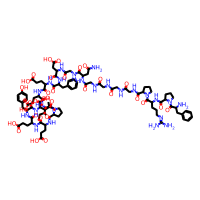
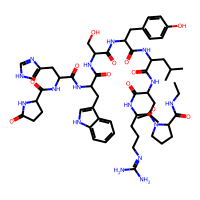
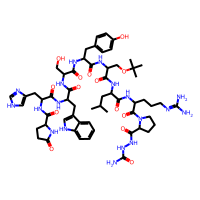

In [ ]:
#Visualizamos las primeras líneas del nuevo DataFrame
DATA.head(3)

In [ ]:
DATA.shape

(2374, 5)

,Name,Smiles,DataBase,NEW_SMILES,Molecule
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,
3,DB00027,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...,FDA,CC(C)CC(NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(...,
4,DB00035,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,FDA,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,
...,...,...,...,...,...
2369,Roxithromycin,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,Senoterapeutico,CC[C@H]1OC(=O)C(C)[C@@H](O[C@H]2C[C@@](C)(OC)[...,
2370,Tamatinib (R406),COc1cc(Nc2ncc(F)c(Nc3ccc4c(n3)NC(=O)C(C)(C)O4)...,Senoterapeutico,COc1cc(N=c2nc(N=c3ccc4c([nH]3)NC(=O)C(C)(C)O4)...,
2371,MitoTam,CN(CCOc1ccc(cc1)C(=C(c1ccccc1)CCCCCCCCCC[P+](c...,Senoterapeutico,CN(C)CCOc1ccc(C(=C(CCCCCCCCCC[P+](c2ccccc2)(c2...,
2372,Panobinostat,Cc1[nH]c2ccccc2c1CCNCc1ccc(/C=C/C(=O)NO)cc1,Senoterapeutico,Cc1[nH]c2ccccc2c1CCNCc1ccc(/C=C/C(O)=NO)cc1,

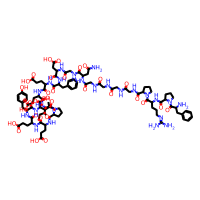
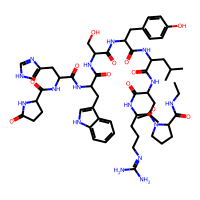
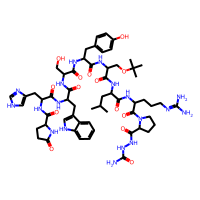
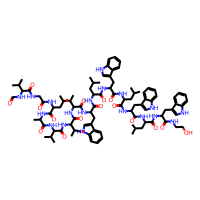
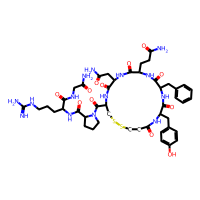
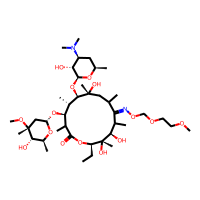
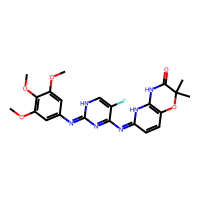
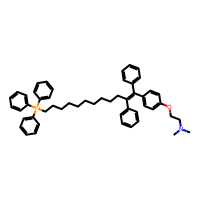
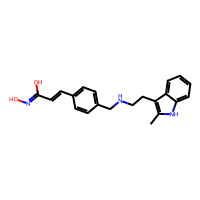
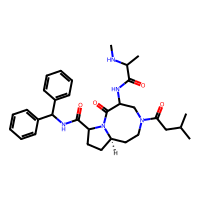

In [ ]:
DATA

,Name,Smiles,DataBase,NEW_SMILES,Molecule
2354,Fisetin,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)ccc12,Senoterapeutico,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)ccc12,
2355,Curcumin,COc1cc(/C=C/C(=O)/C=C(O)/C=C/c2ccc(O)c(OC)c2)c...,Senoterapeutico,COc1cc(C=CC(=O)CC(=O)C=Cc2ccc(O)c(OC)c2)ccc1O,
2356,o-Vanillin (curcumin metabolite),COc1cccc(C=O)c1O,Senoterapeutico,COc1cccc(C=O)c1O,
2357,EF-24 (curcumin analogue),O=C1/C(=C/c2ccccc2F)CNC/C1=C\c1ccccc1F,Senoterapeutico,O=C1/C(=C/c2ccccc2F)CNC/C1=C\c1ccccc1F,
2358,Piperlongumine,COc1cc(/C=C/C(=O)N2CCC=CC2=O)cc(OC)c1OC,Senoterapeutico,COc1cc(/C=C/C(=O)N2CC=CCC2=O)cc(OC)c1OC,
2359,Proscillaridin A,C[C@@H]1O[C@@H](O[C@@H]2C=C3CC[C@@H]4[C@H](CC[...,Senoterapeutico,C[C@@H]1O[C@@H](O[C@@H]2C=C3CC[C@@H]4[C@H](CC[...,
2360,Ouabain,C[C@@H]1O[C@@H](O[C@H]2C[C@@H](O)[C@]3(CO)[C@H...,Senoterapeutico,C[C@@H]1O[C@@H](O[C@H]2C[C@@H](O)[C@]3(CO)[C@H...,
2361,Ouabagenin,C[C@]12C[C@@H](O)[C@H]3[C@@H](CC[C@]4(O)C[C@@H...,Senoterapeutico,C[C@]12C[C@@H](O)[C@H]3[C@@H](CC[C@]4(O)C[C@@H...,
2362,Digoxin,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,Senoterapeutico,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,
2363,Bufalin,C[C@]12CC[C@H](O)C[C@H]1CC[C@@H]1[C@@H]2CC[C@]...,Senoterapeutico,C[C@]12CC[C@H](O)C[C@H]1CC[C@@H]1[C@@H]2CC[C@]...,

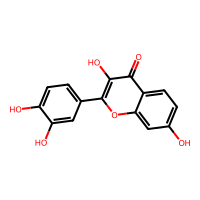
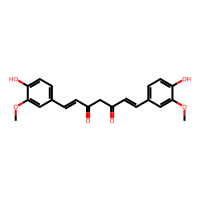
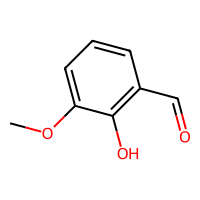
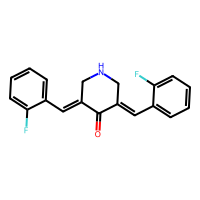
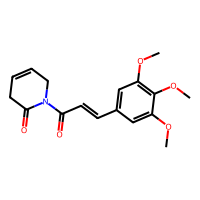
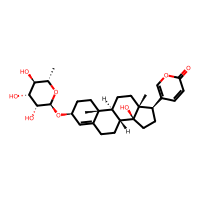
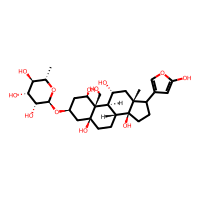
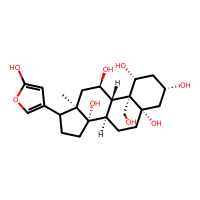
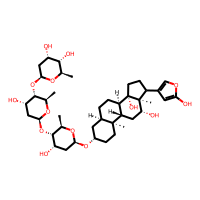
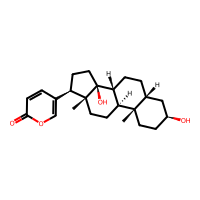
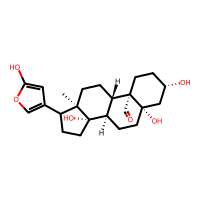
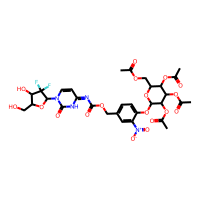
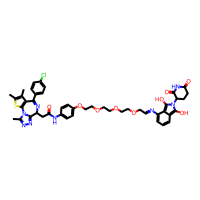
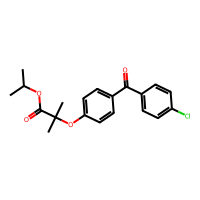
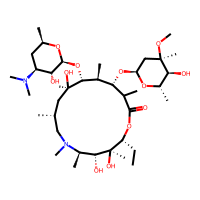
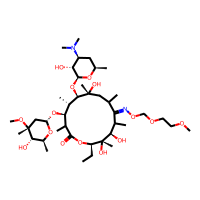
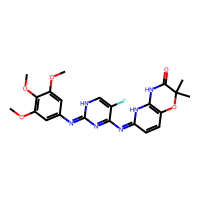
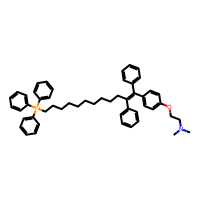
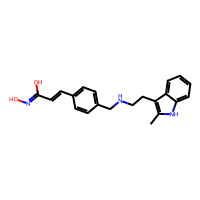
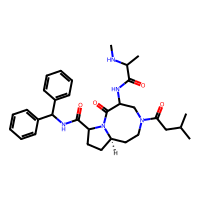

In [ ]:
DATA.tail(20)

In [ ]:
# Eliminar smiles no leído por RDKit
DATA = DATA[DATA["NEW_SMILES"] != "Error 1"]
# Eliminar smiles que contiene átomos no permitidos
DATA = DATA[DATA["NEW_SMILES"] != "Error 2"]
# Eliminar otros errores
DATA = DATA[DATA["NEW_SMILES"] != "Something else was found"].reset_index(drop=True)

,Name,Smiles,DataBase,NEW_SMILES,Molecule,QED
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,,0.014175
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,,0.015135
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,,0.010267

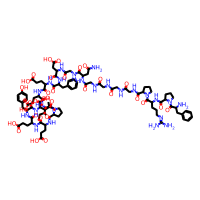
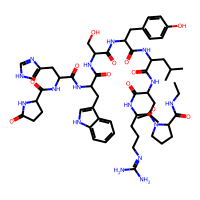
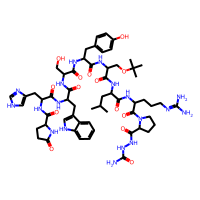

In [ ]:
#Calculamos el QED
QEDlist = []

for mol in DATA['Molecule']:
    QED = Chem.QED.qed(mol)
    QEDlist.append(QED)
DATA['QED']=QEDlist
DATA.head(3)

<ipython-input-176-d4b7560b64df>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="DataBase", y="QED", data=DATA, palette="BuPu")


Text(0, 0.5, 'QED')

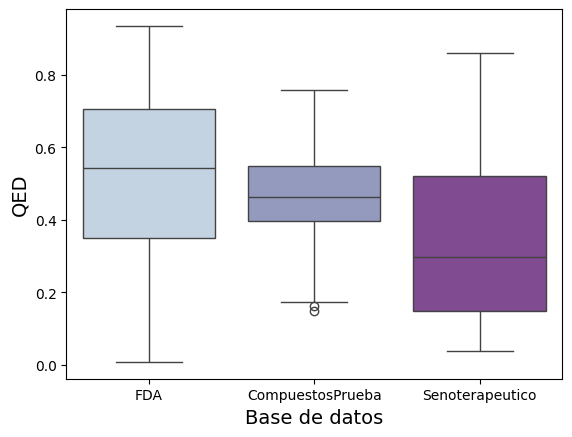

In [ ]:
#Graficar boxplot
ax = sns.boxplot(x="DataBase", y="QED", data=DATA, palette="BuPu")
#Título de ejes
plt.xlabel('Base de datos', size=14)
plt.ylabel('QED', size=14)

## *Synthetic Accessibility Score*

El SAscore asigna un número entre 1 (fácil de obtener) y 10 (muy difícil de obtener) a un compuesto para estimar su accesibilidad sintética. Está basado en una combinación de contribuciones de fragmentos y una penalización por complejidad. El punto de corte suele establecerse en SAscore menor o igual a 6. <br>
Referencia: https://doi.org/10.1186/1758-2946-1-8

In [ ]:
#Importar módulos necesarios:
import os
from rdkit.Chem import RDConfig
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

,Name,Smiles,DataBase,NEW_SMILES,Molecule,QED,SA
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,,0.014175,7.364281
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,,0.015135,5.898815
2,DB00014,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,FDA,CC(C)CC(NC(=O)C(COC(C)(C)C)NC(=O)C(Cc1ccc(O)cc...,,0.010267,6.138788

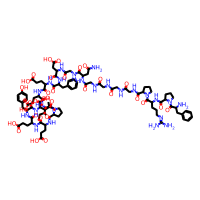
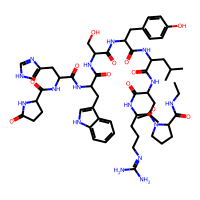
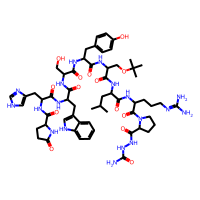

In [ ]:
#Calcular SAscore
SAlist = []

for mol in DATA['Molecule']:
    SA = sascorer.calculateScore(mol)
    SAlist.append(SA)
DATA['SA']=SAlist
DATA.head(3)

<ipython-input-179-3ddab689d85f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="DataBase", y="SA", data=DATA, palette="Blues")


Text(0, 0.5, 'SAscore')

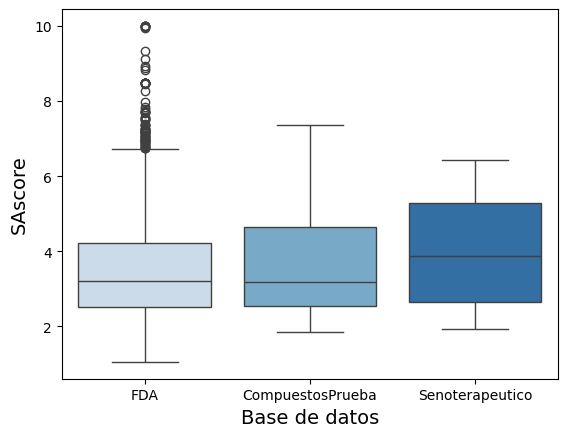

In [ ]:
#Graficar boxplot
ax = sns.boxplot(x="DataBase", y="SA", data=DATA, palette="Blues")
#Título de ejes
plt.xlabel('Base de datos', size=14)
plt.ylabel('SAscore', size=14)

In [ ]:
#Eliminar molecula tipo Mol y guardar el archivo en formato .csv
DATA.drop("Molecule", axis=1, inplace=True)
DATA.to_csv("DATA_QED_FDA_prueba_test.csv", index=False)

## *Raincloud plots*

Los *raincloud plots* o gráficos de nube combinan la visualización de la distribución (la "nube") y la dispersión de los datos (la "lluvia"). Los gráficos de nube combinan la mitad de un diagrama de violín, la distribución de los datos representados con puntos aleatorios (*jitter*) y una visualización de tendencia central como los diagramas de caja. <br>
El siguiente código está basado en lo publicado en: https://wellcomeopenresearch.org/articles/4-63

In [ ]:
pip -V

pip 23.1.2 from /usr/local/lib/python3.10/dist-packages/pip (python 3.10)


In [ ]:
#Instalar librería para raincloud plots, reiniciar la sesión si al final de la celda aparece la advertencia
!pip install ptitprince

In [ ]:
#Importar librerías necesarias después de reiniciar la sesión
import pandas as pd
import ptitprince as pt
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid") #Estilo predeterminado de las gráficas
import matplotlib.collections as clt

In [ ]:
# Leer base de datos desde Drive
#DATA_P
DATA = "/content/drive/MyDrive/Doctorado/Set de datos/3. Descriptores moleculares/DATA_QED_FDA_prueba_test.csv"
DATA = pd.read_csv(DATA)
DATA.head(2)

,Name,Smiles,DataBase,NEW_SMILES,QED,SA
0,DB00006,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,FDA,CCC(C)C(NC(=O)C(CCC(=O)O)NC(=O)C(CCC(=O)O)NC(=...,0.014175,7.364281
1,DB00007,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,FDA,CCNC(=O)C1CCCN1C(=O)C(CCCN=C(N)N)NC(=O)C(CC(C)...,0.015135,5.898815


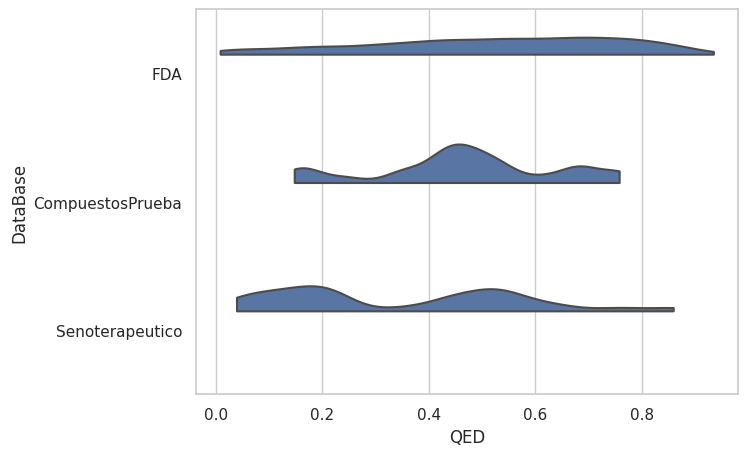

In [ ]:
#Graficar las "nubes"
f, ax = plt.subplots(figsize=(7, 5))
dy="DataBase"; dx="QED"; ort="h"; pal = sns.color_palette(n_colors=1)

ax=pt.half_violinplot( x = dx, y = dy, data = DATA, palette = pal,
      bw = .2, cut = 0.,scale = "area", width = .6, inner = None,
      orient = ort)

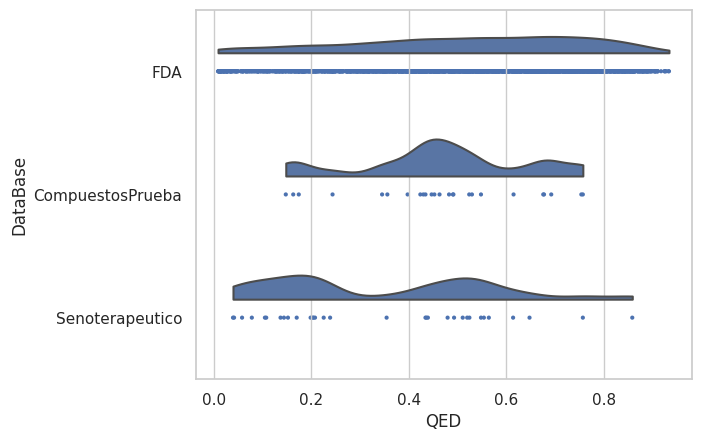

In [ ]:
#Agregar la "lluvia"
ax=pt.half_violinplot( x = dx, y = dy, data = DATA, palette = pal,
      bw = .2, cut = 0.,scale = "area", width = .6, inner = None,
      orient = ort)

ax=sns.stripplot( x = dx, y = dy, data = DATA, palette = pal,
     edgecolor = "white",size = 3, jitter = 0, zorder = 0,
     orient = ort)

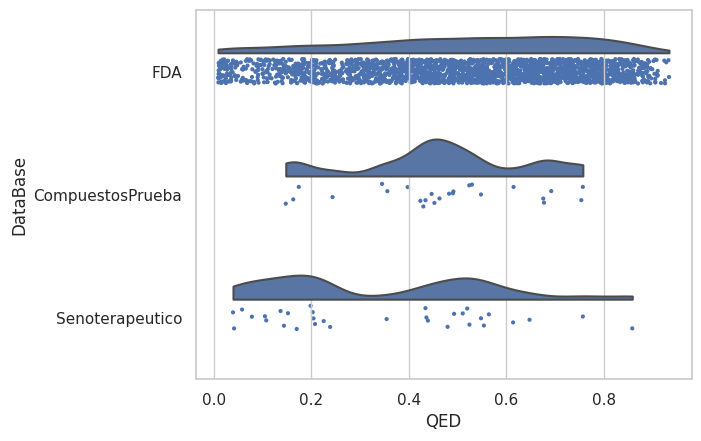

In [ ]:
#"Dispersar la lluvia"
ax=pt.half_violinplot( x = dx, y = dy, data = DATA, palette = pal,
      bw = .2, cut = 0.,scale = "area", width = .6, inner = None,
      orient = ort)

ax=sns.stripplot( x = dx, y = dy, data = DATA, palette = pal,
     edgecolor = "white",size = 3, jitter = 1, zorder = 0,
     orient = ort)

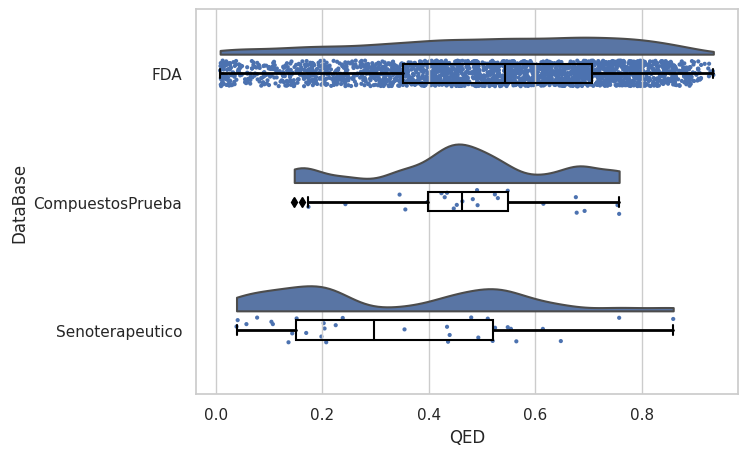

In [ ]:
#Agregar un diagrama de caja para mostrar los cuartiles
f, ax = plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot( x = dx, y = dy, data = DATA, palette = pal,
       bw = .2, cut = 0.,scale = "area", width = .6, inner = None,
       orient = ort)

ax=sns.stripplot( x = dx, y = dy, data = DATA, palette = pal,
       edgecolor = "white", size = 3, jitter = 1, zorder = 0,
       orient = ort)

ax=sns.boxplot( x = dx, y = dy, data = DATA, color = "black",
       width = .15, zorder = 10, showcaps = True,
       boxprops = {'facecolor':'none', "zorder":10}, showfliers=True,
       whiskerprops = {'linewidth':2, "zorder":10},
       saturation = 1, orient = ort)

[Text(0, 0.5, 'QED')]

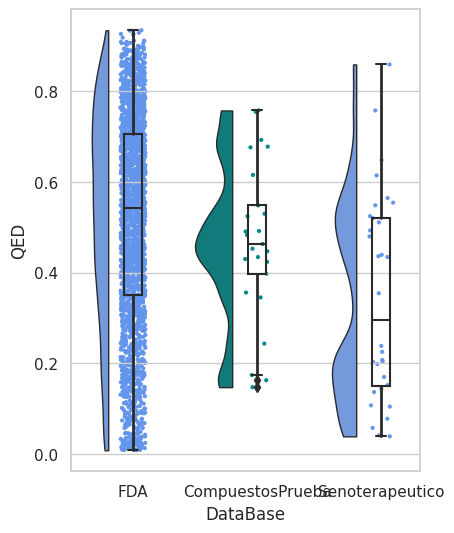

In [ ]:
#Con menos líneas de código:
palette= "cornflowerblue", "#008B8B"

dx = "DataBase"; dy = "QED"; ort = "v"; pal = palette; sigma = .2
f, ax = plt.subplots(figsize=(4.5, 6))

ax=pt.RainCloud(x = dx, y = dy, data = DATA, palette = pal,
      bw = sigma,width_viol = .6, ax = ax, orient = ort)

ax.set(ylabel='QED')

[Text(0.5, 0, 'Base de datos')]

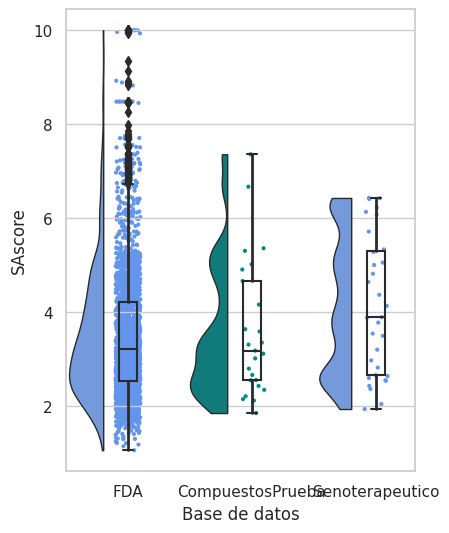

In [ ]:
#Para SAscore
palette= "cornflowerblue", "#008B8B"

dx = "DataBase"; dy = "SA"; ort = "v"; pal = palette; sigma = .2
f, ax = plt.subplots(figsize=(4.5, 6))

ax=pt.RainCloud(x = dx, y = dy, data = DATA, palette = pal,
      bw = sigma,width_viol = .6, ax = ax, orient = ort)

ax.set(ylabel='SAscore')
ax.set(xlabel='Base de datos')